In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [2]:
df=pd.read_excel('Output_df_trfm_full.xlsx')
df.head()

,id,price_log,sqft_living_log,sqft_lot_log,sqft_above_log,sqft_living15_log,sqft_lot15_log,price,sqft_living,sqft_lot,...,renovated,floors_1.5,floors_2.0,floors_2.5,floors_3.0,floors_3.5,condition_2,condition_3,condition_4,condition_5
0,7129300520,12.309987,7.074117,8.639588,7.074117,7.201171,8.639588,221900,1180,5650,...,0,0,0,0,0,0,0,1,0,0
1,6414100192,13.195616,7.852050,8.887791,7.682943,7.433075,8.941153,538000,2570,7242,...,1,0,1,0,0,0,0,1,0,0
2,5631500400,12.100718,6.647688,9.210440,6.647688,7.908755,8.995041,180000,770,10000,...,0,0,0,0,0,0,0,1,0,0
3,2487200875,13.311331,7.581210,8.517393,6.957497,7.215975,8.517393,604000,1960,5000,...,0,0,0,0,0,0,0,0,0,1
4,1954400510,13.142168,7.427144,8.997271,7.427144,7.496097,8.923191,510000,1680,8080,...,0,0,0,0,0,0,0,1,0,0


In [3]:
df.columns

Index(['id', 'price_log', 'sqft_living_log', 'sqft_lot_log', 'sqft_above_log',
       'sqft_living15_log', 'sqft_lot15_log', 'price', 'sqft_living',
       'sqft_lot', 'sqft_above', 'sqft_living15', 'sqft_lot15',
       'sqft_basement', 'House_age', 'bedrooms', 'bathrooms', 'waterfront',
       'view', 'grade', 'renovated', 'floors_1.5', 'floors_2.0', 'floors_2.5',
       'floors_3.0', 'floors_3.5', 'condition_2', 'condition_3', 'condition_4',
       'condition_5'],
      dtype='object')

Since the dataset contains both original values and log values, it was decided to divide them and run XGBoost on both to see the differences.
The analysis starts with the log-transformed variables

In [4]:
X1 = df[['sqft_living_log', 'sqft_lot_log', 'sqft_above_log',
       'sqft_living15_log', 'sqft_lot15_log',
       'sqft_basement', 'House_age', 'bedrooms', 'bathrooms', 'waterfront',
       'view', 'grade', 'renovated', 'floors_1.5', 'floors_2.0', 'floors_2.5',
       'floors_3.0', 'floors_3.5', 'condition_2', 'condition_3', 'condition_4',
       'condition_5']]
y1 = df['price_log']

In [5]:
from sklearn.model_selection import train_test_split

y_bins1 = pd.qcut(y1, q=10, duplicates="drop")
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1,
    y1,
    test_size=0.30,
    random_state=42,
    stratify=y_bins1)

print("Training features:", X_train1.shape)
print("Testing features:", X_test1.shape)
print("Training target:", y_train1.shape)
print("Testing target:", y_test1.shape)

Training features: (15098, 22)
Testing features: (6471, 22)
Training target: (15098,)
Testing target: (6471,)


In [6]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    random_state=42)

xgb_model.fit(X_train1, y_train1)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [7]:
y_pred1 = xgb_model.predict(X_test1)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error)

r21 = r2_score(y_test1, y_pred1)
mae1 = mean_absolute_error(y_test1, y_pred1)
rmse1 = mean_squared_error(y_test1, y_pred1) ** 0.5
mape1 = mean_absolute_percentage_error(y_test1, y_pred1) * 100

print(f"R²   : {r21:.4f}")
print(f"MAE  : {mae1:.4f}")
print(f"RMSE : {rmse1:.4f}")
print(f"MAPE : {mape1:.2f}%")

R²   : 0.7080
MAE  : 0.2210
RMSE : 0.2828
MAPE : 1.70%


In [8]:
#cross validation
return_train_score=True 

from xgboost import XGBRegressor
from sklearn.model_selection import cross_validate

xgb_cv_model = XGBRegressor(
    random_state=42)

cv_results1 = cross_validate(
    xgb_cv_model,
    X_train1,
    y_train1,
    cv=5,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"},
    return_train_score=True)


print("Train Mean R²   :", round(cv_results1["train_r2"].mean(), 4))
print("Test Mean R²    :", round(cv_results1["test_r2"].mean(), 4))

print("Train Mean MAE  :", round(-cv_results1["train_mae"].mean(), 4))
print("Test Mean MAE   :", round(-cv_results1["test_mae"].mean(), 4))

print("Train Mean RMSE :", round(-cv_results1["train_rmse"].mean(), 4))
print("Test Mean RMSE  :", round(-cv_results1["test_rmse"].mean(), 4))

Train Mean R²   : 0.8737
Test Mean R²    : 0.7099
Train Mean MAE  : 0.1435
Test Mean MAE   : 0.2206
Train Mean RMSE : 0.1874
Test Mean RMSE  : 0.2838


A significant overfitting was detected.

In [9]:
from sklearn.model_selection import GridSearchCV

xgb_model = XGBRegressor(
    random_state=42)
param_grid = {
    "n_estimators": [300, 500, 700, 1000],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1]}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train1, y_train1)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV RMSE:")
print(round(-grid_search.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 1000}

Best CV RMSE:
0.2778


In [10]:
import numpy as np
best_xgb_model = grid_search.best_estimator_

y_train_pred1 = best_xgb_model.predict(X_train1)
y_test_pred1 = best_xgb_model.predict(X_test1)

train_rmse1 = np.sqrt(mean_squared_error(y_train1, y_train_pred1))
test_rmse1 = np.sqrt(mean_squared_error(y_test1, y_test_pred1))

train_mae1 = mean_absolute_error(y_train1, y_train_pred1)
test_mae1 = mean_absolute_error(y_test1, y_test_pred1)

train_r21 = r2_score(y_train1, y_train_pred1)
test_r21 = r2_score(y_test1, y_test_pred1)

print("Train R²   :", round(train_r21, 4))
print("Test R²    :", round(test_r21, 4))
print("Train MAE  :", round(train_mae1, 4))
print("Test MAE   :", round(test_mae1, 4))
print("Train RMSE :", round(train_rmse1, 4))
print("Test RMSE  :", round(test_rmse1, 4))

Train R²   : 0.8025
Test R²    : 0.7195
Train MAE  : 0.1832
Test MAE   : 0.2183
Train RMSE : 0.2343
Test RMSE  : 0.2772


Overfitting was reduced after hyperparameter tuning, however a small train-test performance gap remained.

In [11]:
xgb_model_regularized = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    learning_rate=0.05,
    max_depth=4,
    n_estimators=1000)

param_grid_regularized = {
    "gamma": [0, 0.1, 1, 5],
    "reg_lambda": [1, 5, 10, 50, 100],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

grid_search_regularized = GridSearchCV(
    estimator=xgb_model_regularized,
    param_grid=param_grid_regularized,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    verbose=1
)

grid_search_regularized.fit(X_train1, y_train1)

print("Best Regularized Parameters:")
print(grid_search_regularized.best_params_)

print("\nBest Regularized CV RMSE:")
print(round(-grid_search_regularized.best_score_, 4))

Fitting 5 folds for each of 1280 candidates, totalling 6400 fits
Best Regularized Parameters:
{'colsample_bytree': 0.9, 'gamma': 0, 'min_child_weight': 3, 'reg_lambda': 50, 'subsample': 0.8}

Best Regularized CV RMSE:
0.2751


In [12]:
best_regularized_xgb = grid_search_regularized.best_estimator_

y_train_pred1 = best_regularized_xgb.predict(X_train1)
y_test_pred1 = best_regularized_xgb.predict(X_test1)

train_r21 = r2_score(y_train1, y_train_pred1)
test_r21 = r2_score(y_test1, y_test_pred1)

train_mae1 = mean_absolute_error(y_train1, y_train_pred1)
test_mae1 = mean_absolute_error(y_test1, y_test_pred1)

train_rmse1 = np.sqrt(mean_squared_error(y_train1, y_train_pred1))
test_rmse1 = np.sqrt(mean_squared_error(y_test1, y_test_pred1))

print("Train R²   :", round(train_r21, 4))
print("Test R²    :", round(test_r21, 4))
print("Train MAE  :", round(train_mae1, 4))
print("Test MAE   :", round(test_mae1, 4))
print("Train RMSE :", round(train_rmse1, 4))
print("Test RMSE  :", round(test_rmse1, 4))

Train R²   : 0.7844
Test R²    : 0.7236
Train MAE  : 0.1919
Test MAE   : 0.2167
Train RMSE : 0.2448
Test RMSE  : 0.2752


SHAP (SHapley Additive exPlanations) was used to interpret the trained XGBoost model. SHAP values quantify the contribution of each feature to individual predictions and provide a global ranking of feature importance. The summary plot identifies the features with the greatest influence on house price predictions.

In [14]:
import shap
explainer = shap.TreeExplainer(best_regularized_xgb)
shap_values = explainer.shap_values(X_test1)
shap_values_df = pd.DataFrame(
    shap_values,
    columns=X_test1.columns
)

print(shap_values_df.head())

   sqft_living_log  sqft_lot_log  sqft_above_log  sqft_living15_log  \
0        -0.121875     -0.012587       -0.009047          -0.022011   
1        -0.186437     -0.022271       -0.046792          -0.106257   
2         0.036705     -0.037859        0.027245           0.032499   
3        -0.153180      0.008009       -0.021155          -0.144730   
4        -0.096722      0.028084       -0.020136          -0.016025   

   sqft_lot15_log  sqft_basement  House_age  bedrooms  bathrooms  waterfront  \
0       -0.081090      -0.007776   0.164648  0.025478  -0.052053   -0.003384   
1        0.060706      -0.022399  -0.117243  0.005223  -0.038179   -0.002925   
2       -0.078775      -0.010139  -0.116185  0.009661   0.010500   -0.003461   
3       -0.037291      -0.015365   0.129701  0.003690  -0.041772   -0.003368   
4        0.092290       0.036578  -0.099821  0.006999  -0.009659   -0.003241   

   ...  renovated  floors_1.5  floors_2.0  floors_2.5  floors_3.0  floors_3.5  \
0  ...  -0.

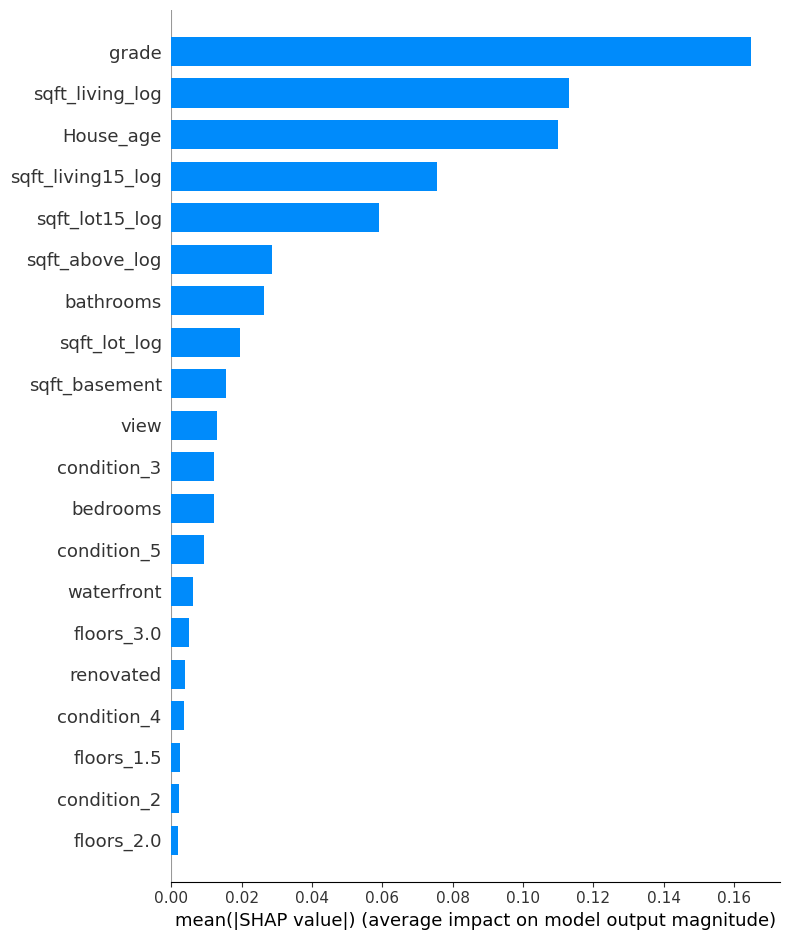

In [15]:
shap.summary_plot(shap_values,X_test1,plot_type="bar")

The SHAP analysis indicates that grade is the most influential feature in predicting house prices, having the largest average impact on the model's output. Features related to house size, such as sqft_living_log and sqft_living15_log, also play a major role, suggesting that larger homes generally contribute to higher predicted prices. House_age is another important factor, indicating that the age of a property influences its market value. Lot size variables (sqft_lot15_log and sqft_lot_log) have a moderate impact, while features such as the number of bathrooms, basement size, view, and bedrooms contribute less to the predictions. Overall, the model relies primarily on property quality (grade), living area, and age, whereas other characteristics have relatively smaller effects on the predicted house prices.

The overfitting was reduced. However, it is still possible to try to reduce it further using the Early Stopping

In [21]:
y_train_bins = pd.qcut(
    y_train1,
    q=10,
    duplicates="drop")

X_train_es, X_val, y_train_es, y_val = train_test_split(
    X_train1,
    y_train1,
    test_size=0.20,
    random_state=42,
    stratify=y_train_bins)

xgb_es_model = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="rmse",
    early_stopping_rounds=50)

xgb_es_model.fit(
    X_train_es,
    y_train_es,
    eval_set=[(X_val, y_val)],
    verbose=False)
print("Best iteration:", xgb_es_model.best_iteration)

y_pred_es = xgb_es_model.predict(X_test1)

r2_es = r2_score(y_test1, y_pred_es)
mae_es = mean_absolute_error(y_test1, y_pred_es)
rmse_es = mean_squared_error(y_test1, y_pred_es) ** 0.5

print(f"R²   : {r2_es:.4f}")
print(f"MAE  : {mae_es:.4f}")
print(f"RMSE : {rmse_es:.4f}")

Best iteration: 837
R²   : 0.7181
MAE  : 0.2193
RMSE : 0.2779


In [22]:
results = xgb_es_model.evals_result()

val_rmse = results["validation_0"]["rmse"]

print("Total trees actually trained:", len(val_rmse))
print("Best iteration:", xgb_es_model.best_iteration)
print("Best validation RMSE:", min(val_rmse))

Total trees actually trained: 888
Best iteration: 837
Best validation RMSE: 0.2785891362820135


In [23]:
y_train_pred_es = xgb_es_model.predict(X_train_es)
y_test_pred_es = xgb_es_model.predict(X_test1)
train_r2_es = r2_score(y_train_es, y_train_pred_es)
train_mae_es = mean_absolute_error(y_train_es, y_train_pred_es)
train_rmse_es = mean_squared_error(y_train_es, y_train_pred_es) ** 0.5
test_r2_es = r2_score(y_test1, y_test_pred_es)
test_mae_es = mean_absolute_error(y_test1, y_test_pred_es)
test_rmse_es = mean_squared_error(y_test1, y_test_pred_es) ** 0.5

print("Train R²   :", round(train_r2_es, 4))
print("Test  R²   :", round(test_r2_es, 4))
print("Train MAE  :", round(train_mae_es, 4))
print("Test  MAE  :", round(test_mae_es, 4))
print("Train RMSE :", round(train_rmse_es, 4))
print("Test  RMSE :", round(test_rmse_es, 4))

Train R²   : 0.8063
Test  R²   : 0.7181
Train MAE  : 0.182
Test  MAE  : 0.2193
Train RMSE : 0.2324
Test  RMSE : 0.2779


Early stopping did not improve the generalization performance in this experiment. Hyperparameter tuning produced better test performance and a smaller train-test gap, therefore the tuned model was selected as the final model.

To compare the performance of log-transformed and raw features, the model was retrained using the original variables.

In [24]:
df.columns

Index(['id', 'price_log', 'sqft_living_log', 'sqft_lot_log', 'sqft_above_log',
       'sqft_living15_log', 'sqft_lot15_log', 'price', 'sqft_living',
       'sqft_lot', 'sqft_above', 'sqft_living15', 'sqft_lot15',
       'sqft_basement', 'House_age', 'bedrooms', 'bathrooms', 'waterfront',
       'view', 'grade', 'renovated', 'floors_1.5', 'floors_2.0', 'floors_2.5',
       'floors_3.0', 'floors_3.5', 'condition_2', 'condition_3', 'condition_4',
       'condition_5'],
      dtype='object')

In [25]:
X = df[['sqft_living','sqft_lot', 'sqft_above', 'sqft_living15', 'sqft_lot15',
       'sqft_basement', 'House_age', 'bedrooms', 'bathrooms', 'waterfront',
       'view', 'grade', 'renovated', 'floors_1.5', 'floors_2.0', 'floors_2.5',
       'floors_3.0', 'floors_3.5', 'condition_2', 'condition_3', 'condition_4','condition_5']]
y = df['price']

In [26]:
y_bins = pd.qcut(y, q=10, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y_bins)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (15098, 22)
Testing features: (6471, 22)
Training target: (15098,)
Testing target: (6471,)


In [27]:
xgb_model = XGBRegressor(
    random_state=42)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [28]:
y_pred = xgb_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

R²   : 0.7632
MAE  : 116624.7734
RMSE : 177416.7559
MAPE : 23.89%


In [29]:
xgb_cv_model = XGBRegressor(
    random_state=42)

cv_results = cross_validate(
    xgb_cv_model,
    X_train,
    y_train,
    cv=5,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    },
    return_train_score=True
)

print("Train Mean R²   :", round(cv_results["train_r2"].mean(), 4))
print("Test Mean R²    :", round(cv_results["test_r2"].mean(), 4))
print("Train Mean MAE  :", round(-cv_results["train_mae"].mean(), 4))
print("Test Mean MAE   :", round(-cv_results["test_mae"].mean(), 4))
print("Train Mean RMSE :", round(-cv_results["train_rmse"].mean(), 4))
print("Test Mean RMSE  :", round(-cv_results["test_rmse"].mean(), 4))

Train Mean R²   : 0.9336
Test Mean R²    : 0.7323
Train Mean MAE  : 71134.2062
Test Mean MAE   : 117921.5969
Train Mean RMSE : 94686.0984
Test Mean RMSE  : 189482.9875


A huge overfitting is present, therefore tuning is needed.

In [30]:
param_grid = {
    "n_estimators": [300, 500, 700, 1000],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1]
}
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    verbose=1)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV RMSE:")
print(round(-grid_search.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000}

Best CV RMSE:
184357.8781


In [31]:
best_xgb_model = grid_search.best_estimator_

y_train_pred = best_xgb_model.predict(X_train)
y_test_pred = best_xgb_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train R²   :", round(train_r2, 4))
print("Test R²    :", round(test_r2, 4))
print("Train MAE  :", round(train_mae, 4))
print("Test MAE   :", round(test_mae, 4))
print("Train RMSE :", round(train_rmse, 4))
print("Test RMSE  :", round(test_rmse, 4))

Train R²   : 0.8447
Test R²    : 0.771
Train MAE  : 103599.5
Test MAE   : 116789.8047
Train RMSE : 144816.1264
Test RMSE  : 174468.2494


In [32]:
xgb_model_regularized = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    learning_rate=0.05,
    max_depth=3,
    n_estimators=1000)
param_grid_regularized = {
    "gamma": [0, 0.1, 1, 5],
    "reg_lambda": [1, 5, 10, 50, 100],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

grid_search_regularized = GridSearchCV(
    estimator=xgb_model_regularized,
    param_grid=param_grid_regularized,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    verbose=1)

grid_search_regularized.fit(X_train, y_train)

print("Best Regularized Parameters:")
print(grid_search_regularized.best_params_)

print("\nBest Regularized CV RMSE:")
print(round(-grid_search_regularized.best_score_, 4))

Fitting 5 folds for each of 1280 candidates, totalling 6400 fits
Best Regularized Parameters:
{'colsample_bytree': 0.9, 'gamma': 0, 'min_child_weight': 1, 'reg_lambda': 5, 'subsample': 1.0}

Best Regularized CV RMSE:
182079.7375


In [33]:
best_regularized_xgb = grid_search_regularized.best_estimator_

y_train_pred = best_regularized_xgb.predict(X_train)
y_test_pred = best_regularized_xgb.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Train R²   :", round(train_r2, 4))
print("Test R²    :", round(test_r2, 4))
print("Train MAE  :", round(train_mae, 4))
print("Test MAE   :", round(test_mae, 4))
print("Train RMSE :", round(train_rmse, 4))
print("Test RMSE  :", round(test_rmse, 4))

Train R²   : 0.8337
Test R²    : 0.7718
Train MAE  : 106101.8203
Test MAE   : 117666.1406
Train RMSE : 149860.8618
Test RMSE  : 174134.074


EARLY STOPPING

In [34]:
y_train_bins = pd.qcut(
    y_train,
    q=10,
    duplicates="drop")

X_train_es, X_val, y_train_es, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train_bins)

print("Training set for early stopping:", X_train_es.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

xgb_es_model = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="rmse",
    early_stopping_rounds=80)

xgb_es_model.fit(
    X_train_es,
    y_train_es,
    eval_set=[(X_val, y_val)],
    verbose=False)
print("Best iteration:", xgb_es_model.best_iteration)

y_pred_es = xgb_es_model.predict(X_test)

r2_es = r2_score(y_test, y_pred_es)
mae_es = mean_absolute_error(y_test, y_pred_es)
rmse_es = mean_squared_error(y_test, y_pred_es) ** 0.5

print(f"R²   : {r2_es:.4f}")
print(f"MAE  : {mae_es:.4f}")
print(f"RMSE : {rmse_es:.4f}")

Training set for early stopping: (12078, 22)
Validation set: (3020, 22)
Test set: (6471, 22)
Best iteration: 891
R²   : 0.7659
MAE  : 117803.3359
RMSE : 176398.4784


In [35]:
best_xgb_model = grid_search.best_estimator_

y_pred_best = best_xgb_model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = mean_squared_error(y_test, y_pred_best) ** 0.5

print(f"R²   : {r2_best:.4f}")
print(f"MAE  : {mae_best:.4f}")
print(f"RMSE : {rmse_best:.4f}")

R²   : 0.7710
MAE  : 116789.8047
RMSE : 174468.2494


In [36]:
y_train_pred_es = xgb_es_model.predict(X_train_es)
y_test_pred_es = xgb_es_model.predict(X_test)

train_r2_es = r2_score(y_train_es, y_train_pred_es)
train_mae_es = mean_absolute_error(y_train_es, y_train_pred_es)
train_rmse_es = mean_squared_error(y_train_es, y_train_pred_es) ** 0.5

test_r2_es = r2_score(y_test, y_test_pred_es)
test_mae_es = mean_absolute_error(y_test, y_test_pred_es)
test_rmse_es = mean_squared_error(y_test, y_test_pred_es) ** 0.5

print("Train R²   :", round(train_r2_es, 4))
print("Test  R²   :", round(test_r2_es, 4))
print("Train MAE  :", round(train_mae_es, 4))
print("Test  MAE  :", round(test_mae_es, 4))
print("Train RMSE :", round(train_rmse_es, 4))
print("Test  RMSE :", round(test_rmse_es, 4))

Train R²   : 0.8545
Test  R²   : 0.7659
Train MAE  : 102450.2969
Test  MAE  : 117803.3359
Train RMSE : 142006.4314
Test  RMSE : 176398.4784


In [37]:
explainer = shap.TreeExplainer(best_regularized_xgb)
shap_values = explainer.shap_values(X_test)
shap_values_df = pd.DataFrame(
    shap_values,
    columns=X_test.columns)

print(shap_values_df.head())

    sqft_living     sqft_lot   sqft_above  sqft_living15    sqft_lot15  \
0 -74546.000000  -615.688782 -4853.992188  -31757.759766 -25902.548828   
1 -81893.515625   209.273590 -9026.407227  -54690.093750  36688.238281   
2  -8774.957031 -2113.093018  7897.873535   16398.835938 -28679.695312   
3 -88119.312500  5563.941895 -4789.979492  -69326.859375 -17711.509766   
4 -56454.910156  3154.970703 -3620.570068  -11499.564453  40257.867188   

   sqft_basement     House_age      bedrooms     bathrooms   waterfront  ...  \
0   -2991.865234  84723.031250  12649.297852 -17493.343750 -2507.671631  ...   
1   -8599.734375 -32697.568359  10863.970703 -14472.793945 -2590.888916  ...   
2   -4269.966797 -67884.359375   3388.076172  -5843.621094 -2982.488037  ...   
3   -6403.683594  74761.140625   2469.313721 -15422.252930 -2563.836670  ...   
4   10142.654297 -53255.960938   3625.060547  -8730.753906 -2740.113770  ...   

     renovated  floors_1.5  floors_2.0  floors_2.5   floors_3.0  floors_3.

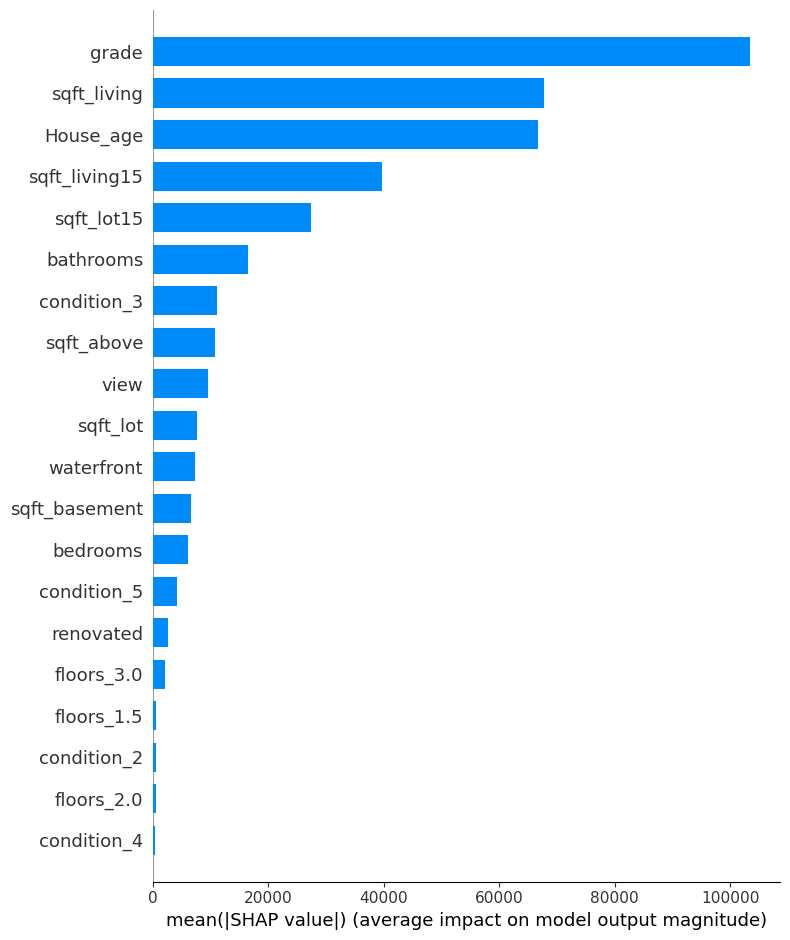

In [38]:
shap.summary_plot(shap_values,X_test,plot_type="bar")

The SHAP feature importance analysis shows that grade is the strongest predictor of house prices, having the largest influence on the model's predictions. Features related to property size, including sqft_living and sqft_living15, are also highly important, indicating that larger homes tend to have higher predicted values. House_age has a substantial impact as well, suggesting that the age of a property plays an important role in determining its price. Other variables, such as lot size, number of bathrooms, and above-ground living area, have a moderate influence, while characteristics including view, waterfront, bedrooms, renovation status, and floor levels contribute relatively little. Overall, the model relies primarily on the quality, size, and age of a property when estimating house prices.

Early stopping did not improve the generalization performance in this experiment. Hyperparameter tuning produced better test performance and a smaller train-test gap, therefore the tuned model was selected as the final model.

Comparing the performance of XGBoost trained on log-transformed values (Train R² = 0.78, Test R² = 0.72) and raw values (Train R² = 0.83, Test R² = 0.77), the model trained on the raw values achieved better predictive performance. Therefore, the tuned XGBoost model trained on the raw target values, without early stopping, was selected as the final model.

Although log transformation can improve the performance of some regression models by reducing skewness, the XGBoost model performed better on the original target values. This suggests that the tree-based model was able to capture the relationships in the data without requiring transformation of the response variable.